# Figures: Performance vs GPT-4.1 Baseline

This notebook generates **6 figures** (one per delta-CSV), each with **two panels**:

- **Left:** $\Delta$RMSE vs GPT-4.1 baseline (lower is better)
- **Right:** $\Delta$Correlation vs GPT-4.1 baseline (higher is better)

Per-variation estimates and 95% CIs are read directly from the precomputed `results/*_metrics_delta.csv` files.

The **E-Net** reference band (blue) is computed once from `df_paired_val.csv` using a paired bootstrap over the 20 designs.


In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 12


def find_repo_root(start: Path | None = None) -> Path:
    """Find the repo root so paths work whether we run from repo root or /plots."""
    if start is None:
        start = Path.cwd()
    start = start.resolve()
    for p in [start] + list(start.parents):
        if (p / 'science-data_and_code').exists() and (p / 'results').exists() and (p / 'plots').exists():
            return p
    raise FileNotFoundError('Could not find repo root from: ' + str(start))


ROOT = find_repo_root()
RESULTS_DIR = ROOT / 'results'
DATA_PATH = ROOT / 'science-data_and_code/data/processed_data/df_paired_val.csv'
BASELINE_PATH = RESULTS_DIR / 'prediction_baseline_41.csv'


In [10]:
def rmse(a: np.ndarray, b: np.ndarray) -> float:
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return float(np.sqrt(np.mean((a - b) ** 2)))


def corr(a: np.ndarray, b: np.ndarray) -> float:
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if np.std(a) == 0 or np.std(b) == 0:
        return float('nan')
    return float(np.corrcoef(a, b)[0, 1])


def bootstrap_paired_delta(metric_fn, model_a, model_b, truth, n_boot: int = 10000, seed: int = 42):
    """Paired bootstrap over designs: metric(model_a) - metric(model_b)."""
    model_a = np.asarray(model_a, dtype=float)
    model_b = np.asarray(model_b, dtype=float)
    truth = np.asarray(truth, dtype=float)

    rng = np.random.default_rng(seed)
    n = len(truth)
    vals = np.empty(n_boot, dtype=float)

    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        vals[i] = metric_fn(model_a[idx], truth[idx]) - metric_fn(model_b[idx], truth[idx])

    est = float(np.nanmean(vals))
    lo, hi = np.nanpercentile(vals, [2.5, 97.5])
    return est, float(lo), float(hi)


# --- Load truth, E-Net, and GPT-4.1 baseline ---
df_val = pd.read_csv(DATA_PATH)
df_val = df_val.sort_values('CONFIG_configId')

truth = (df_val['treatment_itt_efficiency'].to_numpy(dtype=float) * 100)
enet = (df_val['elastic_prereg_pred'].to_numpy(dtype=float) * 100)

q_cols = [f'Q{i}' for i in range(1, 21)]
df_base = pd.read_csv(BASELINE_PATH, index_col=0)
baseline = df_base.loc['baseline', q_cols].to_numpy(dtype=float)

# --- Compute E-Net reference bands vs GPT-4.1 baseline ---
enet_ref_rmse = bootstrap_paired_delta(rmse, enet, baseline, truth, n_boot=10000, seed=42)
enet_ref_corr = bootstrap_paired_delta(corr, enet, baseline, truth, n_boot=10000, seed=42)

print('E-Net delta RMSE vs GPT-4.1 baseline:', enet_ref_rmse)
print('E-Net delta Correlation vs GPT-4.1 baseline:', enet_ref_corr)


E-Net delta RMSE vs GPT-4.1 baseline: (-2.1640755043528244, -3.8632125860655373, -0.5135655311742001)
E-Net delta Correlation vs GPT-4.1 baseline: (0.13437064163063342, -0.09631477741726338, 0.4206998788253431)


In [11]:
def random_effects_meta_from_cis(delta_est, ci_low, ci_high):
    """Random-effects meta-analysis over units using per-unit 95% CIs.

    Returns pooled mean + 95% CI and tau^2 (DerSimonian-Laird).
    """
    delta_est = np.asarray(delta_est, dtype=float)
    ci_low = np.asarray(ci_low, dtype=float)
    ci_high = np.asarray(ci_high, dtype=float)

    # Approximate per-unit SE from CI width
    se = (ci_high - ci_low) / (2.0 * 1.96)
    v = se ** 2

    # Keep only finite, positive-variance units
    mask = np.isfinite(delta_est) & np.isfinite(v) & (v > 0)
    y = delta_est[mask]
    v = v[mask]

    if len(y) < 2:
        raise ValueError('Not enough valid units to run random-effects meta-analysis.')

    # Fixed-effect weights
    w = 1.0 / v
    mu_fe = np.sum(w * y) / np.sum(w)

    # DerSimonian-Laird between-unit variance tau^2
    Q = np.sum(w * (y - mu_fe) ** 2)
    df = len(y) - 1
    c = np.sum(w) - (np.sum(w ** 2) / np.sum(w))
    tau2 = 0.0 if c <= 0 else max(0.0, (Q - df) / c)

    # Random-effects weights
    w_star = 1.0 / (v + tau2)

    # Pooled random-effects estimate
    mu_re = np.sum(w_star * y) / np.sum(w_star)
    var_mu_re = 1.0 / np.sum(w_star)
    se_mu_re = np.sqrt(var_mu_re)

    # 95% CI (normal approx)
    ci_lo_re = mu_re - 1.96 * se_mu_re
    ci_hi_re = mu_re + 1.96 * se_mu_re

    return float(mu_re), float(ci_lo_re), float(ci_hi_re), float(tau2)


def add_reference_band(ax, ref, label='E-Net from integrative experiments', color='tab:blue', alpha=0.45):
    """Add reference band (95% CI) + point estimate line."""
    est, lo, hi = ref
    ax.axhspan(lo, hi, color=color, alpha=alpha, zorder=0)
    ax.axhline(est, color=color, linestyle=':', linewidth=1.5, zorder=1)
    return Line2D([0], [0], color=color, linestyle=':', linewidth=1.5, label=label)


def plot_delta_forest(
    delta_est,
    ci_low,
    ci_high,
    *,
    ax,
    better_is: str,
    ylabel: str,
    xlabel: str,
    enet_ref=None,
    arrow_direction: str,
    show_summary: bool = True,
    legend_loc: str = 'upper left',
    avg_text_loc: str = 'top',
):
    """Forest plot of delta metric vs baseline using precomputed 95% CIs."""
    delta_est = np.asarray(delta_est, dtype=float)
    ci_low = np.asarray(ci_low, dtype=float)
    ci_high = np.asarray(ci_high, dtype=float)

    n_units = len(delta_est)

    order = np.argsort(delta_est)
    delta_sorted = delta_est[order]
    ci_low_sorted = ci_low[order]
    ci_high_sorted = ci_high[order]

    if better_is == 'lower':
        sig_better = ci_high_sorted < 0
        sig_worse = ci_low_sorted > 0
    elif better_is == 'higher':
        sig_better = ci_low_sorted > 0
        sig_worse = ci_high_sorted < 0
    else:
        raise ValueError("better_is must be 'lower' or 'higher'")

    sig_none = ~(sig_better | sig_worse)

    n_better = int(sig_better.sum())
    n_worse = int(sig_worse.sum())
    n_none = int(sig_none.sum())

    pct_better = 100.0 * n_better / n_units
    pct_worse = 100.0 * n_worse / n_units
    pct_none = 100.0 * n_none / n_units

    x = np.arange(n_units)

    def _plot_mask(mask, color, alpha, markersize, elw):
        if mask.sum() == 0:
            return
        xm = x[mask]
        y = delta_sorted[mask]
        lo = ci_low_sorted[mask]
        hi = ci_high_sorted[mask]
        yerr = np.vstack([y - lo, hi - y])
        ax.errorbar(
            xm,
            y,
            yerr=yerr,
            fmt='o',
            color=color,
            ecolor=color,
            capsize=2,
            elinewidth=elw,
            markersize=markersize,
            alpha=alpha,
            linestyle='none',
        )

    # Not significant (grey), better (green), worse (red)
    _plot_mask(sig_none, '0.7', alpha=0.20, markersize=3, elw=0.5)
    _plot_mask(sig_better, 'tab:green', alpha=0.20, markersize=4, elw=1.0)
    _plot_mask(sig_worse, 'tab:red', alpha=0.20, markersize=4, elw=1.0)

    # Separator and baseline
    gap = min(40, int(n_units * 0.02))
    x_sep = n_units
    x_summary = n_units + gap

    ax.axvline(x_sep, color='0.6', linestyle='-', linewidth=1.5)
    ax.axhline(0.0, linestyle='--', color='black', linewidth=1)

    # E-Net reference band
    enet_handle = None
    if enet_ref is not None:
        enet_handle = add_reference_band(ax, enet_ref)

    # Summary point + CI
    if show_summary:
        try:
            summary_est, summary_lo, summary_hi, _tau2 = random_effects_meta_from_cis(
                delta_est, ci_low, ci_high
            )
        except ValueError:
            summary_est = float(np.mean(delta_est))
            summary_lo = float('nan')
            summary_hi = float('nan')

        if np.isfinite(summary_lo) and np.isfinite(summary_hi):
            yerr_summary = [[summary_est - summary_lo], [summary_hi - summary_est]]
        else:
            yerr_summary = None

        ax.errorbar(
            x_summary,
            summary_est,
            yerr=yerr_summary,
            fmt='s',
            color='black',
            ecolor='black',
            capsize=4,
            elinewidth=1.5,
            markersize=5,
            linestyle='none',
        )

        # Rotated average text next to the summary point
        mean_str = f"{summary_est:.2f}"
        if np.isfinite(summary_lo) and np.isfinite(summary_hi):
            avg_text = f"Average: {mean_str} ({summary_lo:.2f} to {summary_hi:.2f})"
        else:
            avg_text = f"Average: {mean_str}"

        ymin, ymax = ax.get_ylim()
        if avg_text_loc == 'bottom':
            y_text = ymin + 0.05 * (ymax - ymin)
            va_text = 'bottom'
        else:
            y_text = ymax - 0.05 * (ymax - ymin)
            va_text = 'top'
        x_text = x_sep + gap

        ax.text(
            x_text,
            y_text,
            avg_text,
            rotation=90,
            va=va_text,
            ha='center',
            fontsize='x-small',
        )

    # Labels and limits
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    ax.set_xticks([])
    ax.set_xlim(-5, x_summary + gap)

    # Arrow + label outside axis (avoid intruding into the plot area)
    x_arrow = 1.03
    y_top, y_bottom = 0.80, 0.20

    if arrow_direction == 'down':
        xy = (x_arrow, y_bottom)
        xytext = (x_arrow, y_top)
    elif arrow_direction == 'up':
        xy = (x_arrow, y_top)
        xytext = (x_arrow, y_bottom)
    else:
        raise ValueError("arrow_direction must be 'up' or 'down'")

    ax.annotate(
        '',
        xy=xy,
        xytext=xytext,
        xycoords='axes fraction',
        textcoords='axes fraction',
        arrowprops=dict(
            arrowstyle='-|>',
            color='0.5',
            lw=0.8,
        ),
        annotation_clip=False,
    )

    ax.text(
        x_arrow + 0.02,
        (y_top + y_bottom) / 2,
        'better prediction',
        color='0.5',
        rotation=90,
        va='center',
        ha='left',
        fontsize='small',
        transform=ax.transAxes,
        clip_on=False,
    )

    # Legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='w',
               label=f'Significantly improves prediction (n = {n_better}, {pct_better:.1f}%)',
               markerfacecolor='tab:green', markersize=5),
        Line2D([0], [0], marker='o', color='w',
               label=f'No significance (n = {n_none}, {pct_none:.1f}%)',
               markerfacecolor='0.7', markersize=5),
        Line2D([0], [0], marker='o', color='w',
               label=f'Significantly worsens prediction (n = {n_worse}, {pct_worse:.1f}%)',
               markerfacecolor='tab:red', markersize=5),
    ]
    if enet_handle is not None:
        legend_elements.append(enet_handle)

    ax.legend(handles=legend_elements, loc=legend_loc, frameon=False, fontsize='small')

    return ax


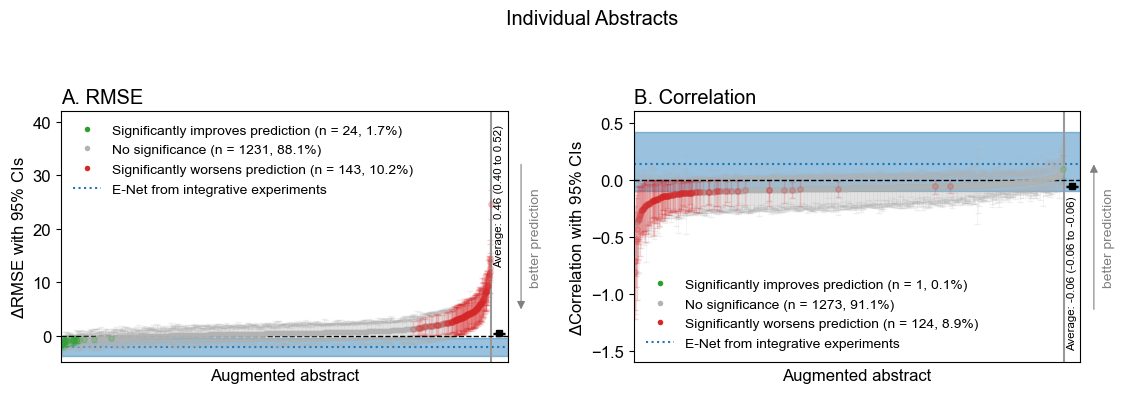

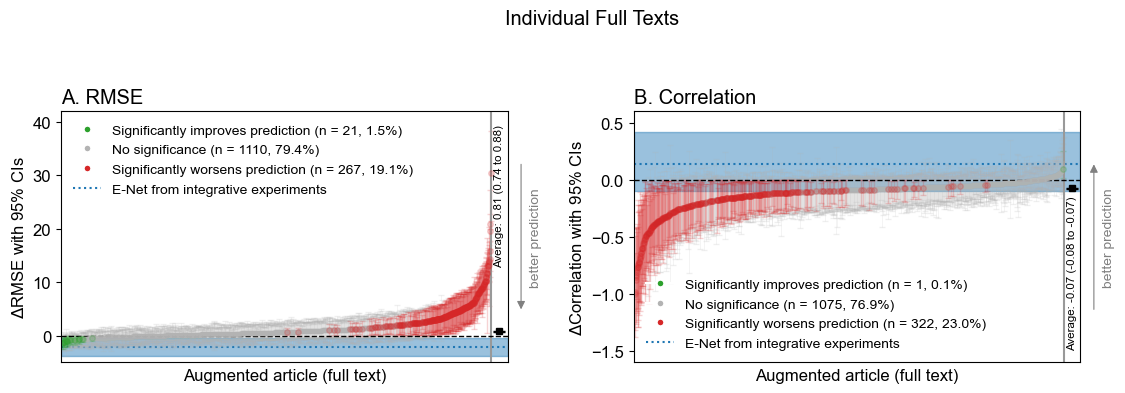

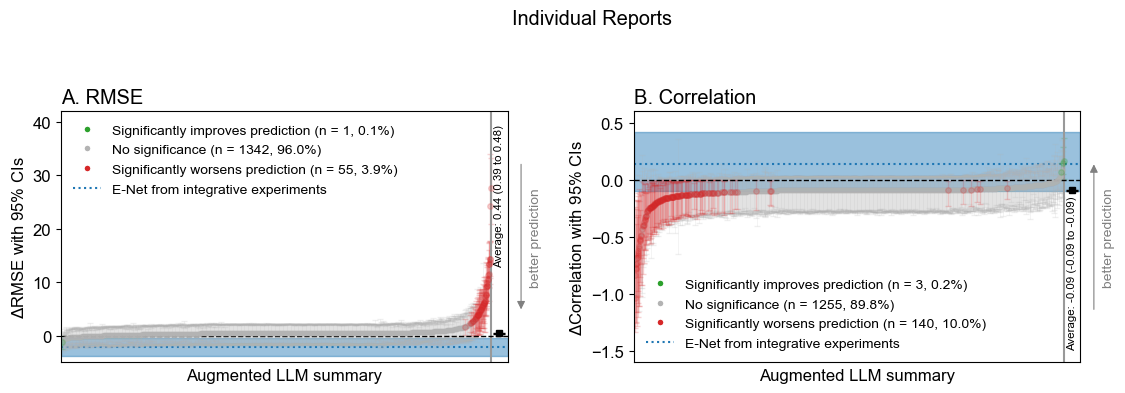

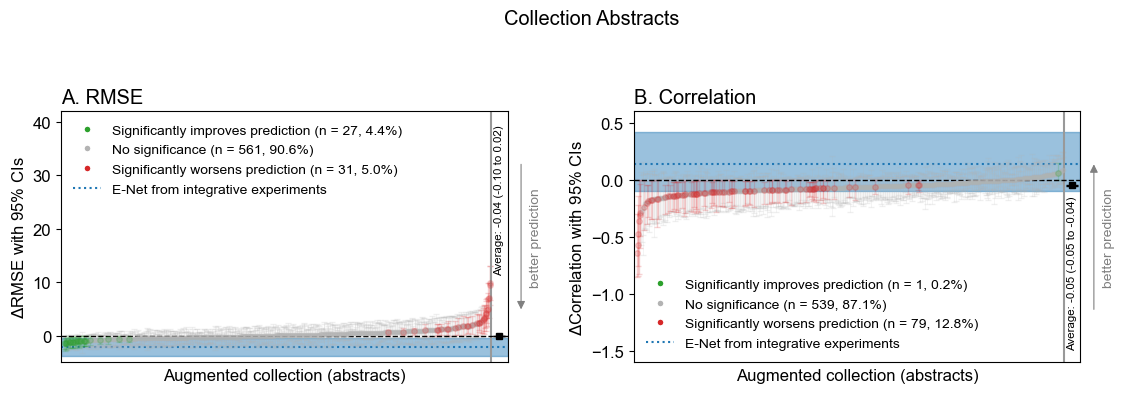

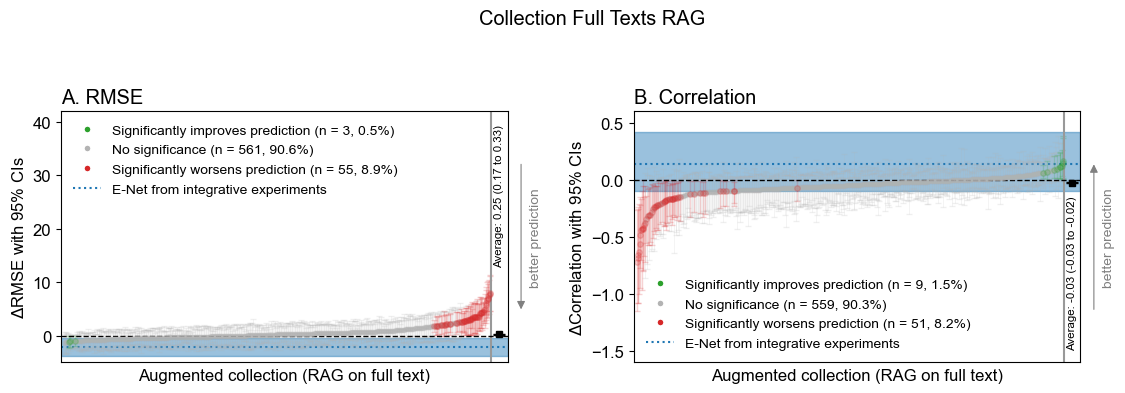

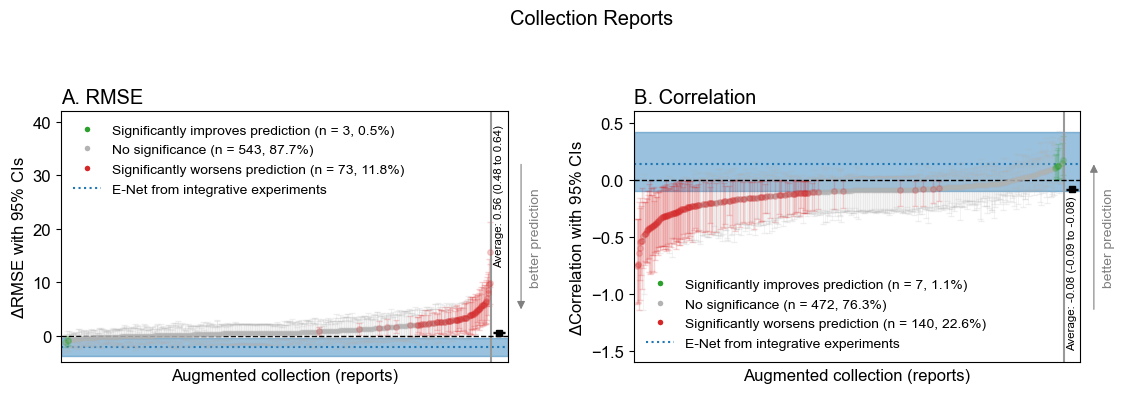

In [12]:
fig_specs = [
    {
        'title': 'Individual Abstracts',
        'csv': RESULTS_DIR / 'prediction_251105_individual_abstract_41_combined_metrics_delta.csv',
        'xlabel': 'Augmented abstract',
    },
    {
        'title': 'Individual Full Texts',
        'csv': RESULTS_DIR / 'prediction_251105_individual_fulltext_41_combined_metrics_delta.csv',
        'xlabel': 'Augmented article (full text)',
    },
    {
        'title': 'Individual Reports',
        'csv': RESULTS_DIR / 'prediction_251105_individual_report_41_metrics_delta.csv',
        'xlabel': 'Augmented LLM summary',
    },
    {
        'title': 'Collection Abstracts',
        'csv': RESULTS_DIR / 'prediction_251110_abstracts_41_metrics_delta.csv',
        'xlabel': 'Augmented collection (abstracts)',
    },
    {
        'title': 'Collection Full Texts RAG',
        'csv': RESULTS_DIR / 'prediction_251110_RAG_41_metrics_delta.csv',
        'xlabel': 'Augmented collection (RAG on full text)',
    },
    {
        'title': 'Collection Reports',
        'csv': RESULTS_DIR / 'prediction_251110_report_41_metrics_delta.csv',
        'xlabel': 'Augmented collection (reports)',
    },
]

for spec in fig_specs:
    df = pd.read_csv(spec['csv'], index_col=0)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # --- Left: ΔRMSE (lower is better) ---
    ax_rmse = axes[0]
    ax_rmse.set_ylim(-5, 42)
    plot_delta_forest(
        df['delta_rmse'].to_numpy(),
        df['delta_rmse_ci_low'].to_numpy(),
        df['delta_rmse_ci_high'].to_numpy(),
        ax=ax_rmse,
        better_is='lower',
        ylabel=r'$\Delta$RMSE with 95% CIs',
        xlabel=spec['xlabel'],
        enet_ref=enet_ref_rmse,
        arrow_direction='down',
        show_summary=True,
    )
    ax_rmse.set_title('A. RMSE', loc='left')

    # --- Right: ΔCorrelation (higher is better) ---
    ax_corr = axes[1]
    ax_corr.set_ylim(-1.6, 0.6)
    plot_delta_forest(
        df['delta_correlation'].to_numpy(),
        df['delta_correlation_ci_low'].to_numpy(),
        df['delta_correlation_ci_high'].to_numpy(),
        ax=ax_corr,
        better_is='higher',
        ylabel=r'$\Delta$Correlation with 95% CIs',
        xlabel=spec['xlabel'],
        enet_ref=enet_ref_corr,
        arrow_direction='up',
        show_summary=True,
        legend_loc='lower left',
        avg_text_loc='bottom',
    )
    ax_corr.set_title('B. Correlation', loc='left')

    fig.suptitle(spec['title'])
    plt.tight_layout(rect=[0, 0, 0.95, 0.92])
    plt.show()
